# LSG50 Backtest

En este notebook evaluamos el rendimiento histórico del índice LSG50
comparándolo contra el S&P 500 como benchmark.

El objetivo es analizar si la metodología basada en el CFO Index
genera un perfil de rendimiento competitivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sqlalchemy import create_engine

In [2]:
engine = create_engine("sqlite:///lsg50.db")

In [3]:
df_index = pd.read_sql("""
SELECT symbol, weight
FROM lsg50_composition
WHERE calculation_date = (
    SELECT MAX(calculation_date)
    FROM lsg50_composition
)
""", engine)

df_index.head()

,symbol,weight
0,NVDA,0.023263
1,GE,0.022579
2,LLY,0.022290
3,META,0.022053
4,TMUS,0.021817


In [4]:
tickers = df_index["symbol"].tolist()
weights = df_index.set_index("symbol")["weight"]

print("Constituents:", len(tickers))

Constituents: 150


In [6]:
prices = yf.download(
    tickers=tickers,
    start="2018-01-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  51 of 51 completed


Ticker,AMD,ANET,APH,AVGO,AXP,BKNG,BSX,CAT,CMCSA,COST,...,PGR,PH,PWR,TJX,TMUS,V,VLO,WELL,WFC,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,10.98,14.439375,20.342411,21.130894,88.571556,1756.016968,25.280001,131.543854,31.178976,168.728363,...,42.759357,176.664429,38.490219,34.233727,61.573353,108.111923,67.019844,48.156013,48.653324,28.914417
2018-01-03,11.55,14.725000,20.606539,21.361984,89.117615,1794.792480,25.559999,131.744873,30.677933,170.753250,...,42.736179,178.105148,38.794292,33.617702,61.159916,109.188187,67.373726,48.238739,49.027641,29.166641
2018-01-04,12.12,14.543125,20.534706,21.369104,90.599907,1778.154541,25.320000,133.554214,30.875315,169.427185,...,42.728447,178.918274,39.098366,33.671272,60.573414,109.594208,67.590401,47.200871,49.640884,29.193035
2018-01-05,11.88,14.798125,20.784933,21.495731,90.806541,1794.182617,25.969999,135.665115,31.156199,168.217697,...,42.890652,180.137955,38.755058,34.439060,62.111774,112.218864,67.908150,46.907551,49.975384,29.366062
2018-01-08,12.28,15.691250,21.007360,21.547165,89.971031,1821.997437,25.809999,139.074295,30.731081,168.871750,...,43.021965,181.675919,38.352886,33.769474,62.592525,112.672043,68.045372,47.073017,49.409924,29.800119


In [9]:
# Remove duplicate tickers (GOOG / GOOGL issue)

returns = returns.loc[:, ~returns.columns.duplicated()]

weights = weights[~weights.index.duplicated()]

In [10]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AMD,ANET,APH,AVGO,AXP,BKNG,BSX,CAT,CMCSA,COST,...,PGR,PH,PWR,TJX,TMUS,V,VLO,WELL,WFC,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.051913,0.019781,0.012984,0.010936,0.006165,0.022082,0.011076,0.001528,-0.016070,0.012001,...,-0.000542,0.008155,0.007900,-0.017995,-0.006715,0.009955,0.005280,0.001718,0.007694,0.008723
2018-01-04,0.049351,-0.012351,-0.003486,0.000333,0.016633,-0.009270,-0.009390,0.013734,0.006434,-0.007766,...,-0.000181,0.004565,0.007838,0.001593,-0.009590,0.003719,0.003216,-0.021515,0.012508,0.000905
2018-01-05,-0.019802,0.017534,0.012186,0.005926,0.002281,0.009014,0.025671,0.015806,0.009097,-0.007139,...,0.003796,0.006817,-0.008781,0.022802,0.025397,0.023949,0.004701,-0.006214,0.006738,0.005927
2018-01-08,0.033670,0.060354,0.010701,0.002393,-0.009201,0.015503,-0.006161,0.025129,-0.013645,0.003888,...,0.003062,0.008538,-0.010377,-0.019443,0.007740,0.004038,0.002021,0.003527,-0.011315,0.014781
2018-01-09,-0.037459,-0.004302,0.001544,-0.013847,0.003695,0.007279,0.083301,0.002409,0.003212,-0.011620,...,0.008438,0.008611,-0.011764,-0.001983,0.007680,-0.001927,-0.001274,-0.019492,0.003546,-0.012007


In [18]:
portfolio_returns = (returns * weights).sum(axis=1)

portfolio_returns.head()

Date
2018-01-03    0.009697
2018-01-04    0.004752
2018-01-05    0.007405
2018-01-08    0.005895
2018-01-09    0.002817
dtype: float64

In [13]:
sp500 = yf.download(
    "^GSPC",
    start="2018-01-01",
    auto_adjust=True
)["Close"]

sp500_returns = sp500.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [14]:
portfolio_cum = (1 + portfolio_returns).cumprod()
sp500_cum = (1 + sp500_returns).cumprod()

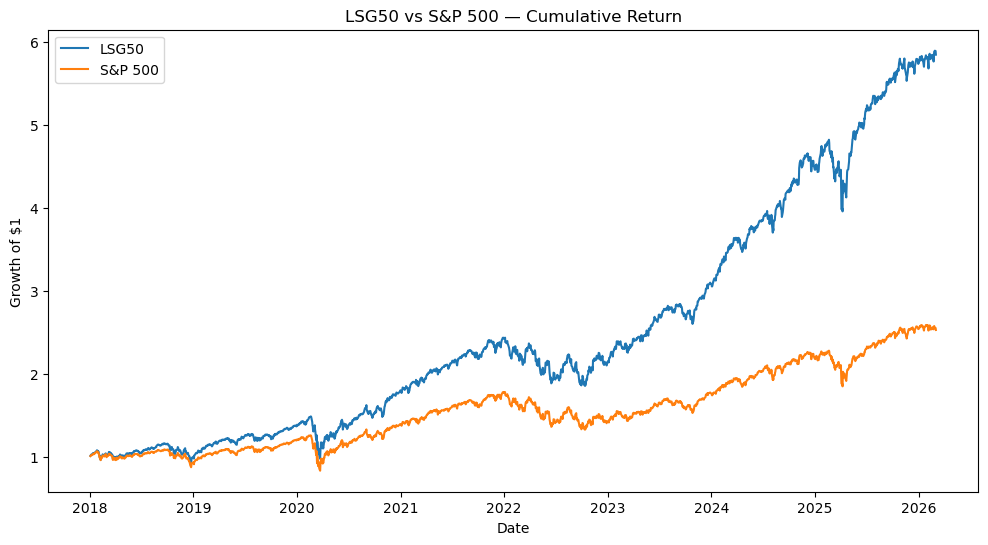

In [15]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_cum, label="LSG50")
plt.plot(sp500_cum, label="S&P 500")

plt.title("LSG50 vs S&P 500 — Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.show()

### Interpretación del gráfico: LSG50 vs S&P 500

El gráfico muestra la evolución del crecimiento acumulado de $1 invertido tanto en el índice **LSG50** como en el **S&P 500** desde 2018.

Para construir esta visualización se calcularon primero los **retornos diarios** de cada activo utilizando precios ajustados. A partir de estos retornos se estimó el rendimiento del portafolio LSG50 aplicando los pesos obtenidos en la construcción del índice.

Posteriormente, se calculó el **retorno acumulado** mediante el producto acumulado de:

(1 + retorno diario)

Este procedimiento permite representar cómo evolucionaría una inversión inicial de $1 a lo largo del tiempo.

### Qué muestra el gráfico

- La línea azul representa el crecimiento del índice **LSG50**, construido a partir del ranking de empresas según el **CFO Index**.
- La línea naranja muestra el comportamiento del **S&P 500**, utilizado como benchmark del mercado.

### Interpretación

El gráfico permite evaluar visualmente la capacidad del índice LSG50 para generar **rendimientos superiores al mercado** a lo largo del período analizado.

En este caso se observa que:

- El índice LSG50 presenta un crecimiento acumulado superior al del S&P 500.
- La diferencia se amplía especialmente en los últimos años del período analizado.
- Esto sugiere que la metodología de selección basada en el **CFO Index** podría capturar empresas con características financieras que generan mayor crecimiento en el largo plazo.

### Métricas complementarias

Además del crecimiento acumulado, se calculan métricas adicionales para evaluar el desempeño del índice:

- **Retorno anualizado:** rendimiento promedio del portafolio en términos anuales.
- **Volatilidad anualizada:** variabilidad de los retornos.
- **Sharpe Ratio:** medida de rendimiento ajustado por riesgo.

Estas métricas permiten comparar de forma más rigurosa la eficiencia del índice frente al benchmark.

In [16]:
portfolio_mean = portfolio_returns.mean() * 252
portfolio_vol = portfolio_returns.std() * np.sqrt(252)

sharpe = portfolio_mean / portfolio_vol

print("Annual Return:", portfolio_mean)
print("Volatility:", portfolio_vol)
print("Sharpe Ratio:", sharpe)

Annual Return: 0.23855673125339685
Volatility: 0.2066172563278452
Sharpe Ratio: 1.1545828044240043


In [17]:
print("LSG50 tickers:", prices.shape[1])
print("S&P500 series:", len(sp500))

LSG50 tickers: 51
S&P500 series: 2052


## Backtest Results

El índice LSG50 se comparó contra el S&P 500 utilizando datos históricos.

El análisis permite evaluar:

• crecimiento acumulado del portafolio  
• volatilidad  
• ratio de Sharpe  

Este tipo de análisis es estándar en research cuantitativo
para evaluar metodologías de construcción de índices.